<a href="https://colab.research.google.com/github/serdararici/btk-datathon-2026/blob/main/v2_feature_engineering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Datathon 2026 — v2: Feature Engineering
**Goal:** Improve baseline by creating meaningful features  
**Previous:** v1 baseline → Public MSE 99.09  
**Author:** Serdar Arıcı | **Date:** June 2026

In [1]:
# ============================================================
# SECTION 1: SETUP
# ============================================================

from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

# Paths
DATA_PATH    = '/content/drive/MyDrive/Colab Notebooks/btk-datathon-2026/'
DATASET_PATH = DATA_PATH + 'datasets/'
OUTPUT_PATH  = DATA_PATH + 'outputs/'

# Load data
train = pd.read_csv(DATASET_PATH + 'train.csv', encoding='utf-8-sig')
test  = pd.read_csv(DATASET_PATH + 'test_x.csv', encoding='utf-8-sig')

print(f"Train: {train.shape}")
print(f"Test:  {test.shape}")

Mounted at /content/drive
Train: (10000, 47)
Test:  (10000, 46)


In [2]:
# ============================================================
# SECTION 2: FEATURE ENGINEERING
# ============================================================

# Work on copies
train_fe = train.copy()
test_fe  = test.copy()

# Helper function: apply the same feature engineering to both datasets
def create_features(df):
    """Create new engineered features. Applied to both train and test."""

    # ---- 1. AVERAGE TECHNICAL SCORE ----
    # Mean of all technical skill columns
    technical_cols = ['coding_score', 'problem_solving_score', 'data_structures_score',
                      'sql_score', 'machine_learning_score', 'backend_score',
                      'frontend_score', 'cloud_score', 'devops_score']
    df['avg_technical_score'] = df[technical_cols].mean(axis=1)

    # ---- 2. AVERAGE SOFT SKILL SCORE ----
    soft_cols = ['communication_score', 'teamwork_score',
                 'leadership_score', 'presentation_score']
    df['avg_soft_skill_score'] = df[soft_cols].mean(axis=1)

    # ---- 3. EXPERIENCE SCORE ----
    # Weighted combination of real-world experience
    df['experience_score'] = (
        df['internship_count'] * 3 +
        df['real_client_project_count'] * 2 +
        df['freelance_project_count'] * 1 +
        df['hackathon_count'] * 1
    )

    # ---- 4. INTERVIEW SUCCESS RATE ----
    # interviews / applications (add 1 to avoid division by zero)
    df['interview_success_rate'] = df['interviews_attended'] / (df['applications_sent'] + 1)

    # ---- 5. HACKATHON EFFICIENCY ----
    # awards per hackathon (add 1 to avoid division by zero)
    df['hackathon_efficiency'] = df['hackathon_awards'] / (df['hackathon_count'] + 1)

    # ---- 6. GITHUB IMPACT ----
    # repos * avg stars (fill NaN stars with 0 for this calculation only)
    df['github_impact'] = df['github_repo_count'] * df['github_avg_stars'].fillna(0)

    # ---- 7. TOTAL PROJECT COUNT ----
    df['total_project_count'] = (
        df['real_client_project_count'] +
        df['freelance_project_count']
    )

    return df

# Apply to both
train_fe = create_features(train_fe)
test_fe  = create_features(test_fe)

# Show the new features
new_features = ['avg_technical_score', 'avg_soft_skill_score', 'experience_score',
                'interview_success_rate', 'hackathon_efficiency', 'github_impact',
                'total_project_count']

print("New features created:")
print(train_fe[new_features].describe())

New features created:
       avg_technical_score  avg_soft_skill_score  experience_score  \
count         10000.000000          10000.000000      10000.000000   
mean             68.772616             55.365360          8.028600   
std              10.879891              9.735080          4.353605   
min              25.337189             19.157500          0.000000   
25%              61.812118             48.763125          5.000000   
50%              69.014161             55.487500          8.000000   
75%              76.212778             62.088125         11.000000   
max              99.102222             85.302500         29.000000   

       interview_success_rate  hackathon_efficiency  github_impact  \
count            10000.000000          10000.000000   10000.000000   
mean                 0.095723              0.074564      44.685301   
std                  0.055354              0.164084     233.461730   
min                  0.000000              0.000000       0.000000 

In [3]:
# ============================================================
# SECTION 3: ROLE-WEIGHTED TECHNICAL SCORE
# ============================================================

# Each target role has different skill priorities
# A Data Scientist needs ML skills more than frontend skills
# We create a weighted average based on the target role

def create_role_weighted_score(df):
    """
    For each student, compute a weighted average of technical skills
    based on their target role. A higher score means the student's
    skills align well with their target role.
    """

    # Define which skills matter most for each role
    # Weights must reflect real-world job requirements
    role_weights = {
        'Data Scientist':       {'machine_learning_score': 3, 'problem_solving_score': 2,
                                 'sql_score': 2, 'data_structures_score': 1, 'coding_score': 1},
        'Data Analyst':         {'sql_score': 3, 'problem_solving_score': 2,
                                 'machine_learning_score': 1, 'coding_score': 1, 'frontend_score': 1},
        'Backend Developer':    {'backend_score': 3, 'coding_score': 2,
                                 'data_structures_score': 2, 'sql_score': 1, 'devops_score': 1},
        'Frontend Developer':   {'frontend_score': 3, 'coding_score': 2,
                                 'problem_solving_score': 1, 'backend_score': 1, 'data_structures_score': 1},
        'AI Engineer':          {'machine_learning_score': 3, 'coding_score': 2,
                                 'data_structures_score': 2, 'cloud_score': 1, 'problem_solving_score': 1},
        'MLOps Engineer':       {'devops_score': 3, 'machine_learning_score': 2,
                                 'cloud_score': 2, 'backend_score': 1, 'coding_score': 1},
        'Cloud Engineer':       {'cloud_score': 3, 'devops_score': 2,
                                 'backend_score': 2, 'coding_score': 1, 'problem_solving_score': 1},
        'DevOps Engineer':      {'devops_score': 3, 'cloud_score': 2,
                                 'backend_score': 2, 'coding_score': 1, 'problem_solving_score': 1},
        'Cybersecurity Analyst':{'problem_solving_score': 3, 'coding_score': 2,
                                 'backend_score': 2, 'devops_score': 1, 'data_structures_score': 1},
        'Product Analyst':      {'problem_solving_score': 3, 'sql_score': 2,
                                 'machine_learning_score': 1, 'communication_score': 1, 'frontend_score': 1},
        'Software Developer':   {'coding_score': 3, 'data_structures_score': 2,
                                 'backend_score': 2, 'problem_solving_score': 1, 'frontend_score': 1},
    }

    weighted_scores = []

    for _, row in df.iterrows():
        role = row['target_role']

        if role in role_weights:
            weights = role_weights[role]
            total_weight = sum(weights.values())

            # Weighted average: sum(skill * weight) / sum(weights)
            score = sum(row[skill] * w for skill, w in weights.items()) / total_weight
        else:
            # Fallback: use avg_technical_score if role not found
            score = row['avg_technical_score']

        weighted_scores.append(score)

    df['role_weighted_score'] = weighted_scores
    return df

# Apply to both datasets
train_fe = create_role_weighted_score(train_fe)
test_fe  = create_role_weighted_score(test_fe)

print("role_weighted_score created!")
print(train_fe['role_weighted_score'].describe())

# Compare: does role_weighted_score correlate better than avg_technical_score?
print(f"\navg_technical_score correlation:  {train_fe['avg_technical_score'].corr(train_fe['career_success_score']):.4f}")
print(f"role_weighted_score correlation: {train_fe['role_weighted_score'].corr(train_fe['career_success_score']):.4f}")

role_weighted_score created!
count    10000.000000
mean        71.108194
std         11.349757
min         25.447122
25%         63.889424
50%         71.349824
75%         78.885438
max        100.000000
Name: role_weighted_score, dtype: float64

avg_technical_score correlation:  0.3378
role_weighted_score correlation: 0.3357


New features correlation with target:
avg_technical_score       0.337751
role_weighted_score       0.335681
total_project_count       0.254952
avg_soft_skill_score      0.215881
experience_score          0.202049
github_impact             0.099653
hackathon_efficiency      0.043065
interview_success_rate    0.013611
Name: career_success_score, dtype: float64


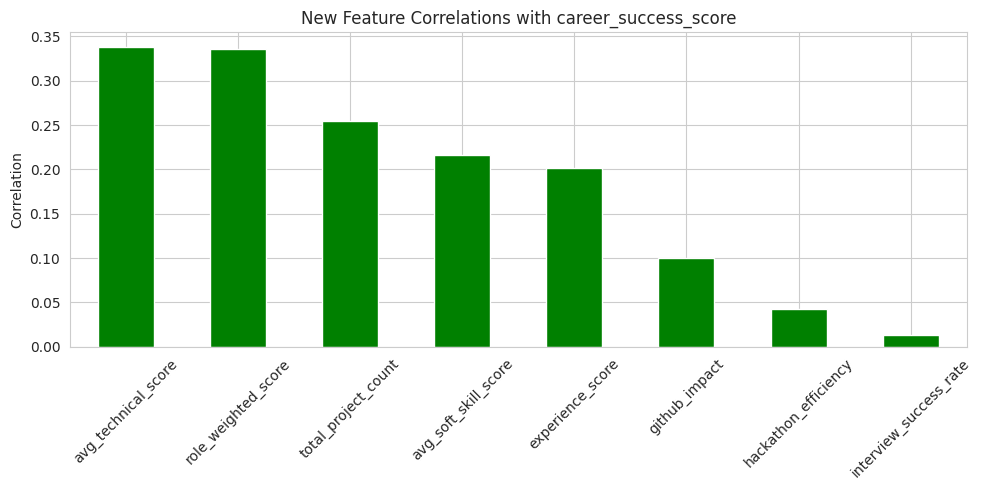

Chart saved!


In [4]:
# ============================================================
# SECTION 4: CORRELATION OF NEW FEATURES WITH TARGET
# ============================================================

new_features = [
    'avg_technical_score', 'avg_soft_skill_score', 'experience_score',
    'interview_success_rate', 'hackathon_efficiency', 'github_impact',
    'total_project_count', 'role_weighted_score'
]

# Correlation with target
correlations = train_fe[new_features + ['career_success_score']].corr()['career_success_score']
correlations = correlations.drop('career_success_score').sort_values(ascending=False)

print("New features correlation with target:")
print(correlations)

# Visualize
plt.figure(figsize=(10, 5))
colors = ['green' if x > 0 else 'red' for x in correlations]
correlations.plot(kind='bar', color=colors)
plt.title('New Feature Correlations with career_success_score')
plt.ylabel('Correlation')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(OUTPUT_PATH + 'feature_engineering_correlations.png', dpi=150)
plt.show()
print("Chart saved!")

In [5]:
# ============================================================
# SECTION 5: PREPROCESSING
# ============================================================

# ---- COPY ----
train_processed = train_fe.copy()
test_processed  = test_fe.copy()

# ---- SMART IMPUTATION: INTERNSHIP DURATION ----
duration_median = train_processed.loc[
    train_processed['internship_count'] > 0,
    'internship_duration_months'
].median()

# Train
train_processed.loc[
    (train_processed['internship_count'] == 0) &
    (train_processed['internship_duration_months'].isnull()),
    'internship_duration_months'
] = 0

train_processed.loc[
    (train_processed['internship_count'] > 0) &
    (train_processed['internship_duration_months'].isnull()),
    'internship_duration_months'
] = duration_median

# Test
test_processed.loc[
    (test_processed['internship_count'] == 0) &
    (test_processed['internship_duration_months'].isnull()),
    'internship_duration_months'
] = 0

test_processed.loc[
    (test_processed['internship_count'] > 0) &
    (test_processed['internship_duration_months'].isnull()),
    'internship_duration_months'
] = duration_median

# ---- MEDIAN IMPUTATION ----
numeric_to_impute = [
    'english_exam_score', 'portfolio_score', 'github_avg_stars',
    'open_source_contribution_count', 'linkedin_profile_score', 'hr_interview_score'
]

medians = {}
for col in numeric_to_impute:
    medians[col] = train_processed[col].median()

train_processed.fillna(medians, inplace=True)
test_processed.fillna(medians, inplace=True)

# ---- ENCODING ----
tier_mapping = {'Tier 1': 4, 'Tier 2': 3, 'Tier 3': 2, 'Tier 4': 1}
train_processed['university_tier'] = train_processed['university_tier'].map(tier_mapping)
test_processed['university_tier']  = test_processed['university_tier'].map(tier_mapping)

# Separate target before OHE
target_col = train_processed['career_success_score'].copy()
train_processed = train_processed.drop(columns=['career_success_score'])

# One-hot encoding
ohe_cols = ['department', 'target_role']
train_processed = pd.get_dummies(train_processed, columns=ohe_cols, dtype=int)
test_processed  = pd.get_dummies(test_processed,  columns=ohe_cols, dtype=int)

# Align
train_processed, test_processed = train_processed.align(
    test_processed, join='left', axis=1, fill_value=0
)

# Drop noise columns
noise_cols = ['hobby', 'preferred_social_media_platform',
              'student_id', 'mentor_feedback_text']
for col in noise_cols:
    if col in train_processed.columns:
        train_processed = train_processed.drop(columns=[col])
    if col in test_processed.columns:
        test_processed = test_processed.drop(columns=[col])

# Add target back
train_processed['career_success_score'] = target_col

# ---- VERIFY ----
print(f"Train shape: {train_processed.shape}")
print(f"Test shape:  {test_processed.shape}")
print(f"\nIn train but not in test: {set(train_processed.columns) - set(test_processed.columns)}")
print(f"In test but not in train: {set(test_processed.columns) - set(train_processed.columns)}")
print(f"\nMissing train: {train_processed.isnull().sum().sum()}")
print(f"Missing test:  {test_processed.isnull().sum().sum()}")

Train shape: (10000, 67)
Test shape:  (10000, 66)

In train but not in test: {'career_success_score'}
In test but not in train: set()

Missing train: 0
Missing test:  0


In [6]:
# ============================================================
# SECTION 6: MODEL - XGBOOST WITH NEW FEATURES
# ============================================================

from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# Split
X = train_processed.drop(columns=['career_success_score'])
y = train_processed['career_success_score']

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Same model parameters as v1 (fair comparison)
model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)
val_preds = model.predict(X_val)

val_mse  = mean_squared_error(y_val, val_preds)
val_rmse = np.sqrt(val_mse)

print(f"V1 Validation MSE:  89.89 | RMSE: 9.48")
print(f"V2 Validation MSE:  {val_mse:.4f} | RMSE: {val_rmse:.4f}")
print(f"\nImprovement: {89.89 - val_mse:.4f} MSE reduction")

V1 Validation MSE:  89.89 | RMSE: 9.48
V2 Validation MSE:  88.2842 | RMSE: 9.3960

Improvement: 1.6058 MSE reduction


Top 20 features:
                              feature  importance
17              project_quality_score    0.159192
40                avg_technical_score    0.101824
30          technical_interview_score    0.050319
47                role_weighted_score    0.042185
18          real_client_project_count    0.039882
62     target_role_Frontend Developer    0.027013
41               avg_soft_skill_score    0.025489
57         target_role_Cloud Engineer    0.024225
25                  github_repo_count    0.021276
24                    portfolio_score    0.021098
45                      github_impact    0.019743
32                communication_score    0.019376
27     open_source_contribution_count    0.018963
59           target_role_Data Analyst    0.018286
2                     graduation_year    0.017346
58  target_role_Cybersecurity Analyst    0.016654
61        target_role_DevOps Engineer    0.014258
44               hackathon_efficiency    0.014179
42                   experience_s

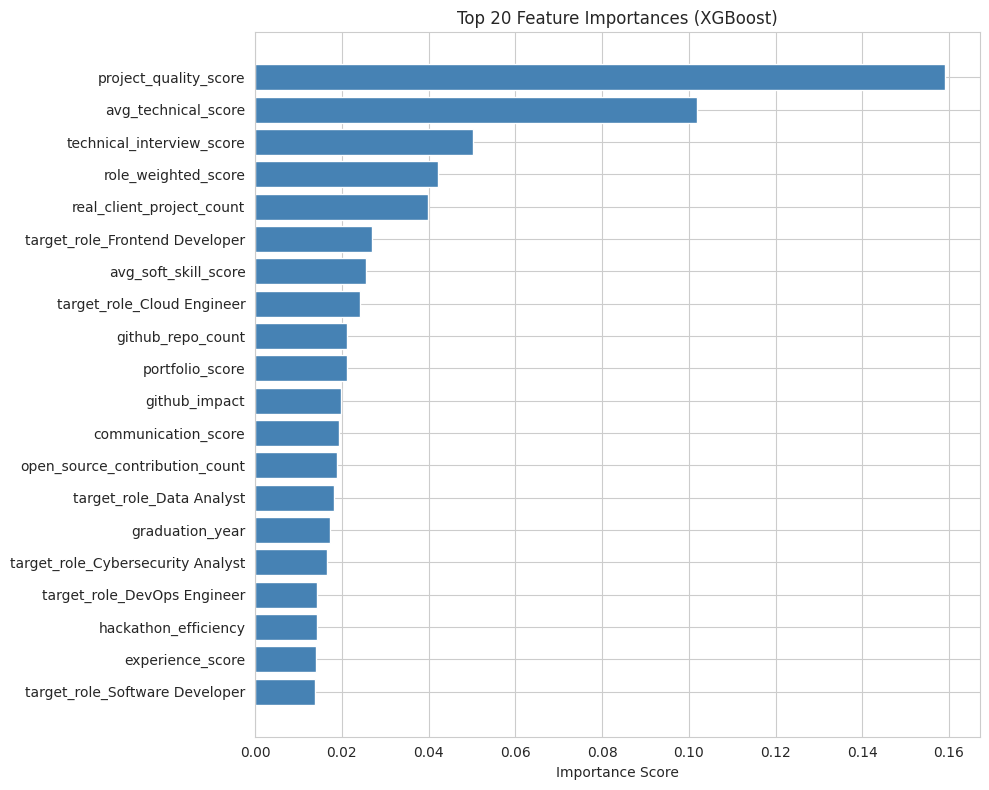

Chart saved!


In [10]:
# ============================================================
# SECTION 7: FEATURE IMPORTANCE
# ============================================================

import pandas as pd

# Get feature importance from trained model
importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

# Top 20 most important features
print("Top 20 features:")
print(importance_df.head(20).to_string())

# Fixed visualization
fig, ax = plt.subplots(figsize=(10, 8))
top20 = importance_df.head(20)
ax.barh(top20['feature'], top20['importance'], color='steelblue')
ax.set_title('Top 20 Feature Importances (XGBoost)')
ax.set_xlabel('Importance Score')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(OUTPUT_PATH + 'feature_importance_v2.png', dpi=150)
plt.show()
print("Chart saved!")

In [11]:
# ============================================================
# SECTION 8: CREATE SUBMISSION
# ============================================================

# Predict on test set
test_preds = model.predict(test_processed)
test_preds = np.clip(test_preds, 0, 100)

# Load original test for student_id
test_original = pd.read_csv(DATASET_PATH + 'test_x.csv', encoding='utf-8-sig')

submission = pd.DataFrame({
    'student_id': test_original['student_id'],
    'career_success_score': test_preds
})

submission.to_csv(OUTPUT_PATH + 'submission_v2.csv', index=False)

print("Submission created!")
print(submission.head())
print(f"\nPrediction range: {test_preds.min():.2f} to {test_preds.max():.2f}")
print(f"Prediction mean:  {test_preds.mean():.2f}")

Submission created!
   student_id  career_success_score
0  STU_010001             63.227879
1  STU_010002             71.278305
2  STU_010003             72.604904
3  STU_010004             97.330467
4  STU_010005             77.340233

Prediction range: 33.98 to 100.00
Prediction mean:  76.23


## v2 Feature Engineering Results

### New Features Created
- avg_technical_score → correlation 0.34, **ranked #2 in importance**
- role_weighted_score → correlation 0.34, ranked #4 in importance
- total_project_count → correlation 0.25
- avg_soft_skill_score → correlation 0.22, ranked #7 in importance
- experience_score → correlation 0.20
- github_impact → correlation 0.10
- hackathon_efficiency → correlation 0.04
- interview_success_rate → correlation 0.01, not in top 20 → candidate for removal

### Model Performance
- V1 Validation MSE: 89.89 | RMSE: 9.48
- V2 Validation MSE: 88.28 | RMSE: 9.40
- Improvement: 1.61 MSE reduction

### Key Findings
- project_quality_score still #1 most important feature (0.159)
- avg_technical_score entered top 2 → feature engineering confirmed useful
- interview_success_rate weak → will drop in v4
- Biggest improvement expected from NLP (v3)